In [10]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import sys
print(sys.executable)
sys.path.insert(1, '../src/')
from config import raw_data_path, univariate_data_path, processed_data_path, models_path, results_path
from preprocessing_modules import create_time_windows_with_labels, create_time_windows_with_metadata
from skopt import gp_minimize
import pandas as pd

/home/nwertheim/miniconda3/bin/python


In [14]:
mat_files_dir = os.path.join('..', '..', '..', '..', '..', 'projects', 'prjs1386', 'clinical_data_cocoon.csv')
data = pd.read_csv(mat_files_dir)


In [17]:
# print(data.head())
print(data.columns)


Index(['participant_id', 'Participant.Status', 'Site.Abbreviation',
       'Participant.Creation.Date', 'inclusion_date', 'is_adult_0_no_1_yes',
       'incl_gestational_age_0_no_1_yes', 'incl_tptb_0_no_1_yes',
       'incl_informed_consent_0_no_1_yes', 'excl_implant_present_0_no_1_yes',
       'excl_silicone_allergy_0_no_1_yes', 'excl_in_labor_0_no_1_yes',
       'start_time_recording.x', 'end_time_recording.x', 'sensor_number',
       'age_mother', 'length_mother', 'pregravid_weight', 'gravida',
       'num_pregnancies_before_16_wks', 'para', 'num_sptb_under_34_wks',
       'num_sptb_above_34_wks_under_37_wks', 'num_cesarean_sections',
       'num_fetus', 'ga_weeks_at_admission', 'ga_days_at_admission',
       'uterus_myomatosus_0_no_1_yes', 'uterine_anomaly_0_no_1_yes',
       'num_contractions_per_10_min_admission', 'intact_membranes_0_no_1_yes',
       'blood_loss_0_no_1_yes', 'infection_0_no_1_yes', 'cervical_length',
       'ffn_0_neg_1_pos_2_not_conducted', 'quant_ffn',
       

In [20]:
cols_of_interest = [
    'age_mother', 'length_mother', 'ga_weeks_at_admission', 'blood_loss_0_no_1_yes',
    'ga_weeks_at_birth'
]

print(data[cols_of_interest].describe())
print(data[cols_of_interest].info())


       age_mother  length_mother  ga_weeks_at_admission  \
count  162.000000     162.000000             161.000000   
mean    30.654321     153.209877              28.664596   
std      5.207879      58.071431               2.058349   
min     18.000000     -99.000000              23.000000   
25%     27.000000     160.000000              27.000000   
50%     31.000000     165.000000              29.000000   
75%     35.000000     171.750000              30.000000   
max     42.000000     186.000000              33.000000   

       num_contractions_per_10_min_admission  blood_loss_0_no_1_yes  \
count                             161.000000             161.000000   
mean                              -10.934783               0.242236   
std                                32.284339               0.429773   
min                               -99.000000               0.000000   
25%                                 0.000000               0.000000   
50%                                 0.0000

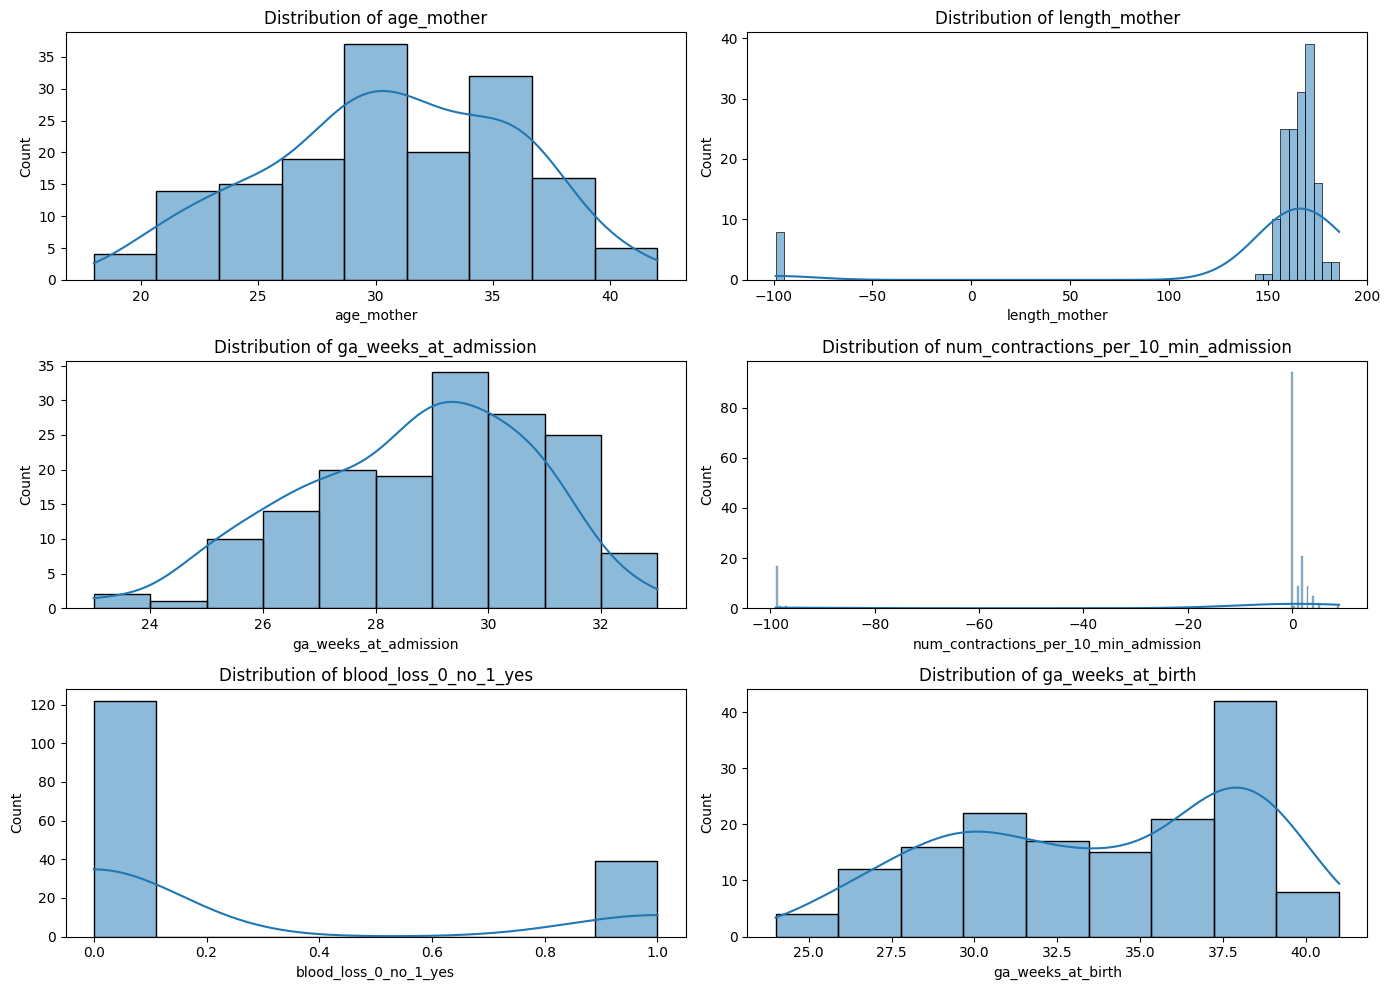

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
for i, col in enumerate(cols_of_interest):
    plt.subplot(3, 2, i+1)
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


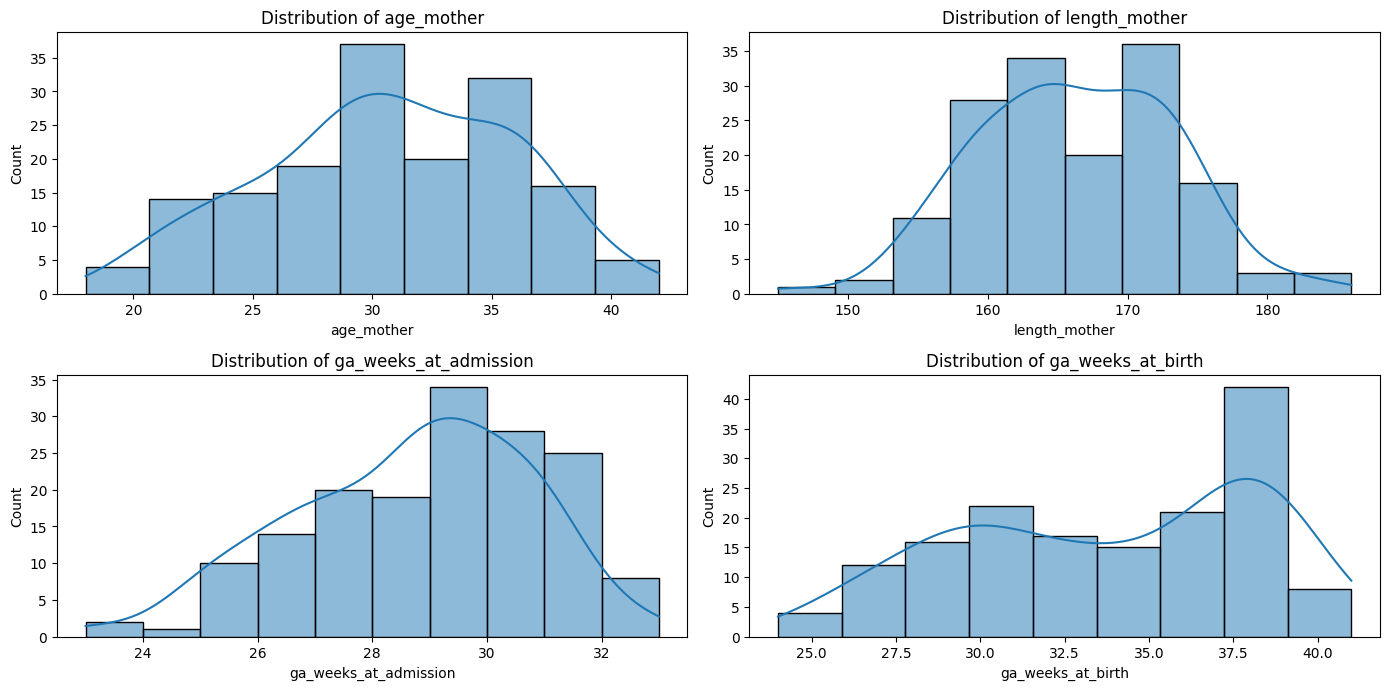

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_of_interest = [
    'age_mother', 'length_mother', 'ga_weeks_at_admission',
    'ga_weeks_at_birth'
]

plt.figure(figsize=(14, 10))

for i, col in enumerate(cols_of_interest):
    plt.subplot(3, 2, i+1)
    
    if col == 'length_mother':
        # Exclude all negative lengths
        sns.histplot(data[data[col] >= 0][col].dropna(), kde=True)
    else:
        sns.histplot(data[col].dropna(), kde=True)
    
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


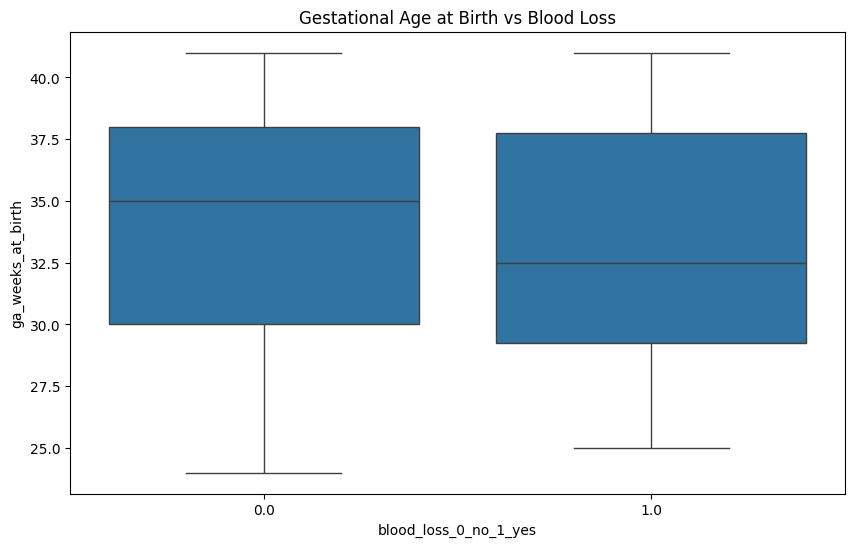